# Annealing Benchmarking and Verification

Here we apply our developed benchmarking strategy to annealers from DWave.

- sub-system: temperature, susceptibility, and flux noise
- system: ???
- application: QML

We will focus on the `advantage2_system1` solver:
- Zephyr graph with $m=12, t=4$
- around 5k qubits and 40k couplers
- biases $h\in [-6,6], J\in [-1,1]$

We will also tile jobs across all areas of the QPU, to compress the number of jobs.

> Note: we should set `auto_scale=False` throughout to ensure the `h,J` values we submit are respected.

## Background

Annealers solve Ising problems:

$$E(x)=\sum{h_ix_i}+\sum{J_{ij}x_ix_j}$$

The freeze-out point for a single qubit is around $s^*\approx 0.68$. Near that point, the distribution of qubit states is a thermal Boltzmann:

$$P(\text{state})\propto e^{-E/k_BT}$$

In [1]:
# imports
from scipy.constants import Planck, Boltzmann
from dwave.system import DWaveSampler
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import time

from dwave.system.temperatures import (
    fast_effective_temperature,
    maximum_pseudolikelihood_temperature,
    maximum_pseudolikelihood,
    background_susceptibility_bqm,
    freezeout_effective_temperature,
    h_to_fluxbias,
)
from random import random
from dimod import BinaryQuadraticModel

In [2]:
# setup

SOLVER = "Advantage2_system1"

# device constants
# taken from the docs and the solver-properties spreadsheet

# B(s*): problem energy scale at single-qubit freeze-out
B_FREEZEOUT_GHZ = 8.06630607

# single-qubit freezeout point
S_STAR          = 0.684

# M_AFM (pH) for Advantage2_system1; used for h->flux conversion
MAFM_PH         = 0.528

In [3]:
# retrieve the working qubit graph
with DWaveSampler(solver=SOLVER) as sampler:
    G = sampler.to_networkx_graph()
print(f"working graph: {G.number_of_nodes()} qubits, {G.number_of_edges()} couplers")

working graph: 4577 qubits, 41514 couplers


## Sub-System Benchmarking

### Temperature

The higher the temperature, the noisier the qubits, i.e. the less likely they are to take the lowest-energy state.

There are two temperatures:

- effective temperature `w` is measured in bias units (same as $h$), and is returned by the DWave functions. We expect $w\approx0.112$
- physical temperature $T$ is in Kelvin and is converted using $T=B(s^*)2\pi\hbar w/2k_B$ with $B(s^*)\approx 8.066\text{ GHz}$. We expect $T\approx 20\text{ mK}$

Then, note that different subsets of qubits will have freeze at different points in the anneal, and thus will report different temperatures:

- single qubits
- coupled spin glass
- multi-qubit cluster

We will focus on single qubits here, but note that we can use clustering to probe the device at other points during the anneal. This has not been implemented yet.

We can measure temperature by fitting a Boltzmann distribution to the measured results:

$$\braket{\sigma_z}=\tanh{\frac{h_0-h}{w}}$$

Therefore, we will sweep $h$ (set all $J$ to 0), and measure the average spin at each. Then, we will fit the above function: the fitted distribution width $w$ is the effective temperature, and $h_0$ absorbs any other bias.

To get a good average, we can do this for a lot of qubits in a single job!

Once we have done the manual implementation, we will cross-check using DWave's own diagnostic functions.

In [ ]:
# setup
TARGET_QUBIT = 1
NUM_ANNEALS = 1000

# we concentrate the sweep near 0
_bias_seeds = np.logspace(-1.2, 0.4, 10) / 10
bias_values = np.array((-_bias_seeds).tolist()[::-1] + [0.0] + _bias_seeds.tolist())

# run, only on one qubit for now
results = []
with DWaveSampler(solver=SOLVER) as sampler:
    for bias in bias_values:
        h = {TARGET_QUBIT: bias}
        res = sampler.sample_ising(h, {}, num_reads=NUM_ANNEALS, label=f"bias={bias:.3f}", auto_scale=False)
        results.append(res)

Effective temperature: 0.112 +-0.003 (h0=-0.002 +-0.001)
Physical temperature: 21.68 +-0.63 mK


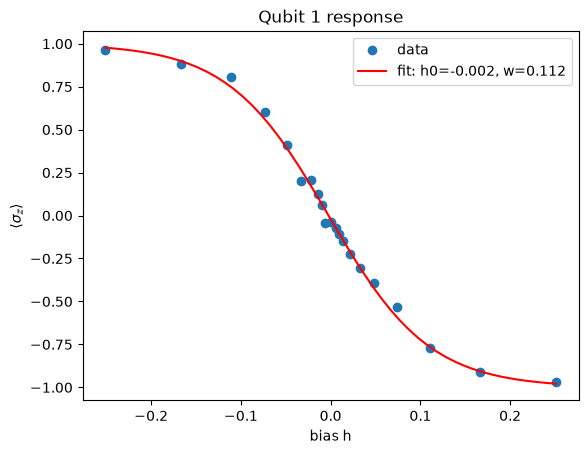

In [46]:
# analyse
avg_spins = [sum([s.sample[TARGET_QUBIT]*s.num_occurrences for s in i.data()])/NUM_ANNEALS for i in results]

def tanh_response(h, h0, w):
    return np.tanh((h0 - h) / w)

def w_to_kelvin(w):
    "Convert an effective temperature w (bias units) to physical temperature T (kelvin)."
    return B_FREEZEOUT_GHZ * 1e9 * Planck * w / (2 * Boltzmann)

popt, pcov = curve_fit(tanh_response, bias_values, avg_spins, p0=[0.0, 0.1])
perr = np.sqrt(np.diag(pcov))

w_tanh, w_tanh_err = popt[1], perr[1]

print(f"Effective temperature: {popt[1]:.3f} +-{perr[1]:.3f} (h0={popt[0]:.3f} +-{perr[0]:.3f})")
print(f"Physical temperature: {w_to_kelvin(popt[1])*1000:.2f} +-{w_to_kelvin(perr[1])*1000:.2f} mK")

plt.plot(bias_values, avg_spins, 'o', label='data')
plt.plot(np.linspace(min(bias_values), max(bias_values)), tanh_response(np.linspace(min(bias_values), max(bias_values)), *popt), 'r-', label=f'fit: h0={popt[0]:.3f}, w={popt[1]:.3f}')
plt.xlabel('bias h')
plt.ylabel(r'$\langle\sigma_z\rangle$')
plt.legend()
plt.title(f"Qubit {TARGET_QUBIT} response")
plt.show()


- `fast_effective_temperature` submits random single-qubit problems, should agree with our results
- `maximum_pseudolikelihood_temperature` experiments on a spin-glass (random $J$), which is a coupled problem with a different freezeout point, and so should have a higher effective temperature

In [ ]:
with DWaveSampler(solver=SOLVER) as sampler:
    w_fast, w_fast_err = fast_effective_temperature(
        sampler=sampler,
        sampler_params = {"num_reads": NUM_ANNEALS},
        nodelist = [TARGET_QUBIT],
        # num_bootstrap_samples=100
    )

    # we need to do a little config for the maximum pseudolikelihood temperature, since it expects a BQM
    bqm_sg = BinaryQuadraticModel.from_ising({}, {e: 1 - 2 * random() for e in sampler.edgelist})
    mpl_samples = sampler.sample(bqm_sg, num_reads=1000, auto_scale=False)
    w_mpl, _ = maximum_pseudolikelihood_temperature(bqm_sg, mpl_samples)

print(f"* fast: w = {w_fast:.4f}")
print(f"* MPL : w = {w_mpl:.4f}  (different freeze-out point)")

* fast: w = 0.1153 ± 0.0000
* MPL : w = 0.1303  (different freeze-out point)


### Susceptibility

$\chi$ is the "leakiness" of the qubits, acting through the couplers:

- a bias on one qubit leaks to the neighbours
- a qubit mediates a weak coupling between two of its neighbours

It modifies the implemented Hamiltonians thusly:

$$\text{BQM}=\text{BQM}(\chi=0)+\chi d\text{BQM}(\text{corrections})$$

Here we used a normalised $\chi=M_{\text{AFM}}\chi_q$ where $\chi_q=dIp/d\Phi_q$ is the _physical_ qubit susceptibility. 

Note that $\chi$ only has an effect when $J\neq 0$! Also, it has a dependency on $s$ and varies through the anneal.

We will measure this by building and sampling from a random spin-glass (zero biases, random couplers). Then, since the final distribution depends on the Hamiltonian, the temperature, and the susceptibility, we can pin the temperature to what we measured in the previous section (at zero couplings so there is no chi-effect) and measure the implied value of chi!

In [ ]:
NUM_ANNEALS = 2000

# create the spin glass
bqm = BinaryQuadraticModel.from_ising({}, {e: 1 - 2 * random() for e in sampler.edgelist})

# sample from it
with DWaveSampler(solver=SOLVER) as sampler:
    samples = sampler.sample(bqm, num_reads=NUM_ANNEALS, auto_scale=False)

# calculate the correction dBQM
dbqm = background_susceptibility_bqm(bqm)

# fit chi
x, _ = maximum_pseudolikelihood(
    bqms = [bqm, dbqm],
    sampleset = samples,
    x0 = [-1/w_fast, 0]
)

w_joint, chi = -1 / x[0], x[1] / x[0]

print(f"Measured chi: {chi:.4f}")
print(f"Seeded chi-free w_fast: {w_fast:.4f}")
print(f"Measured chi-corrected w_joint: {w_joint:.4f}")
print(f"w_joint / w_fast = {w_joint/w_fast:.4f} (close to 1 = trustworthy)")

Measured chi: -0.0178
Assumed chi-free w: 0.1153
Measured chi-corrected w: 0.1273
w_joint / w_fast = 1.1042 (close to 1 = trustworthy)


### $1/f$ Flux Noise

Each superconducting circuit suffers from $1/f$ flux noise causing the bias to drift. In other words, the power spectral density (how much noise occurs as a function of time scale) looks like

$$S(f)=\frac{A^2}{f^\alpha},\quad \alpha\approx0.7-1$$

$A$ is the amplitude of the noise at $1\text{ Hz}$. DWave corrects this drift hourly, so we need to turn that correction off.

To measure this, we set $h=J=0$, disable `flux_drift_compensation`, and record the mean spin as a time series. Then, we can analyse that and fit to extract $\alpha$. 

Again, using a cluster improves the signal.

Note that the longer we run the experiment, the more accuracy we have due to the Fourier conversion: the observable frequency band runs from $1/\text{duration}$ to $1/(s*\text{cadence})$

In [10]:
# sample every CADENCE s for DURATION s

CADENCE, DURATION = 2, 500
TARGET_QUBIT = 1
NUM_ANNEALS = 2000

print(f"Sampling every {CADENCE} s for {DURATION} s...")
print(f"Observable frequency band: {1/DURATION:.3f} Hz to {1/(2*CADENCE):.3f} Hz")
print(f"Expected number of jobs: {DURATION/CADENCE:.0f}")

bqm = BinaryQuadraticModel.from_ising({TARGET_QUBIT: 0}, {})

times = []
results = []

# run
with DWaveSampler(solver=SOLVER) as sampler:
    t0 = time.time()
    while time.time() - t0 < DURATION:
        t_ps = time.time()
        samples = sampler.sample(
            bqm,
            num_reads=NUM_ANNEALS,
            auto_scale=False,
            flux_drift_compensation=False,
            reduce_intersample_correlation=True
        )

        now = time.time()
        times.append(now - t0)
        results.append(samples)
        print(f"Sampled at t = {now - t0:.1f} s")

        time.sleep(max(0, CADENCE-(now-t_ps)))

Sampling every 2 s for 500 s...
Observable frequency band: 0.002 Hz to 0.250 Hz
Expected number of jobs: 250
Sampled at t = 0.0 s
Sampled at t = 2.0 s
Sampled at t = 4.0 s
Sampled at t = 6.0 s
Sampled at t = 8.0 s
Sampled at t = 10.0 s
Sampled at t = 12.0 s
Sampled at t = 14.0 s
Sampled at t = 16.0 s
Sampled at t = 18.0 s
Sampled at t = 20.0 s
Sampled at t = 22.0 s
Sampled at t = 24.0 s
Sampled at t = 26.0 s
Sampled at t = 28.0 s
Sampled at t = 30.0 s
Sampled at t = 32.0 s
Sampled at t = 34.0 s
Sampled at t = 36.0 s
Sampled at t = 38.0 s
Sampled at t = 40.0 s
Sampled at t = 42.0 s
Sampled at t = 44.0 s
Sampled at t = 46.0 s
Sampled at t = 48.0 s
Sampled at t = 50.0 s
Sampled at t = 52.0 s
Sampled at t = 54.0 s
Sampled at t = 56.0 s
Sampled at t = 58.0 s
Sampled at t = 60.0 s
Sampled at t = 62.0 s
Sampled at t = 64.0 s
Sampled at t = 66.0 s
Sampled at t = 68.0 s
Sampled at t = 70.0 s
Sampled at t = 72.0 s
Sampled at t = 74.0 s
Sampled at t = 76.0 s
Sampled at t = 78.0 s
Sampled at t = 8

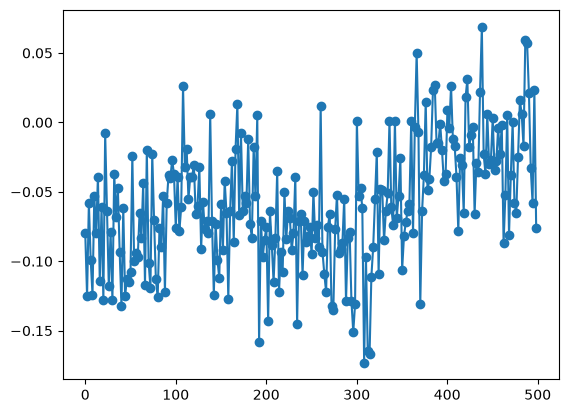

In [ ]:
spins = [sum([s.sample[TARGET_QUBIT]*s.num_occurrences for s in i.data()])/NUM_ANNEALS for i in results]

plt.plot(times, spins, 'o-')

# need to analyse this!

## System-Level Benchmarking

Here we do two experiments:

- native-graph random spin glass
    - weights in $\{\pm5, \pm6, \pm7\}$
    - 100 instances per N
    - N from small to large
    - anneal time sweep? ignore for now
    - spin reversal gauges? ignore for now
    - randomised placement on the real chip
    - gurobi classical solver
- fair degenerate sampling
    - a ring with many degenerate ground states to ensure each is equally sampled

### Native-Graph Random Spin Glass

The hardest problems for an annealer are the ones it was built for: random spin glasses laid out directly on the
native graph, so there is no embedding overhead to confound the result.

Each instance is a randomly-placed connected patch of $N$ qubits with zero biases and integer couplings drawn from
$\{\pm5,\pm6,\pm7\}$. We keep the weights as integers throughout and only divide by 7 at submission time (so that
$J\in[-1,1]$ is respected with `auto_scale=False`); this means energies compare *exactly* against the classical
optimum, with no floating-point slack.

Gurobi gives us that optimum by brute force, so we can ask two questions as $N$ grows:

- how often does the QPU actually land in the ground state?
- when it misses, how far off is its best read?

Note: this submits `NUM_INSTANCES` jobs per size. Tiling instances across the chip would compress that a lot,
but is left out here to keep the proof of concept readable.

In [4]:
# instance generation and classical reference
import gurobipy as gp
import networkx as nx

WEIGHTS = [-7, -6, -5, 5, 6, 7]   # integer coupler weights; divided by J_SCALE on submission
J_SCALE = 7

rng = np.random.default_rng(0)

def random_subgraph(G, N):
    "Grow a connected N-qubit patch from a random seed node, randomising placement on the chip."
    nodes = {int(rng.choice(G.nodes))}
    while len(nodes) < N:
        frontier = list({n for v in nodes for n in G[v]} - nodes)
        nodes.add(int(rng.choice(frontier)))
    return G.subgraph(nodes)

def gurobi_ground_energy(J):
    "Exact Ising ground-state energy for integer couplings J (all h=0), as a binary quadratic program."
    model = gp.Model()
    model.Params.OutputFlag = 0
    x = {v: model.addVar(vtype=gp.GRB.BINARY) for v in {v for edge in J for v in edge}}
    # spins are s = 2x - 1
    model.setObjective(gp.quicksum(w * (2 * x[i] - 1) * (2 * x[j] - 1) for (i, j), w in J.items()))
    model.optimize()
    return round(model.ObjVal)

In [10]:
# run: NUM_INSTANCES random instances at each size
NUM_ANNEALS = 1000
SIZES = [8, 16, 32, 64, 128]
NUM_INSTANCES = 50

# instances = []   # (N, J, exact ground energy, sampleset)
with DWaveSampler(solver=SOLVER) as sampler:
    for N in SIZES:
        for _ in range(NUM_INSTANCES):
            J = {e: int(rng.choice(WEIGHTS)) for e in random_subgraph(G, N).edges}
            E_opt = gurobi_ground_energy(J)
            res = sampler.sample_ising(
                {}, {e: w / J_SCALE for e, w in J.items()},
                num_reads=NUM_ANNEALS, auto_scale=False, label=f"spin glass N={N}",
            )
            instances.append((N, J, E_opt, res))
        print(f"N = {N}: done")

N = 8: done
N = 16: done
N = 32: done
N = 64: done
N = 128: done


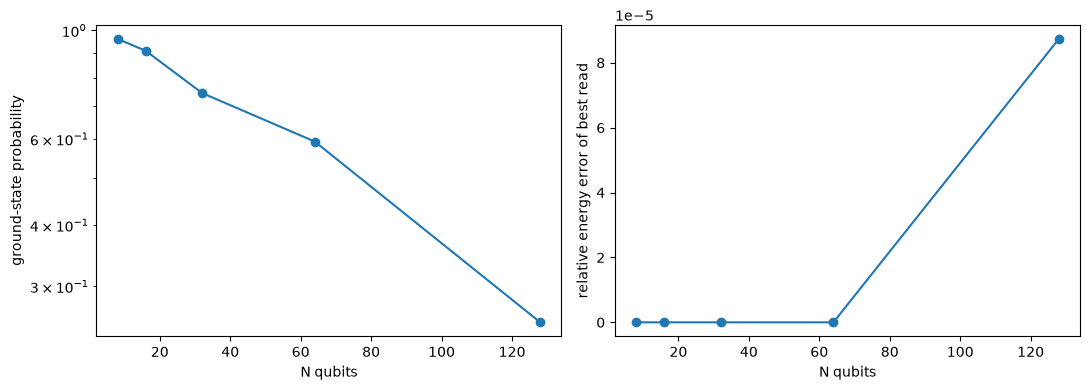

In [11]:
# analyse: how often does the QPU find the true ground state, and how close does it get when it misses?
success, gap = {}, {}
for N, J, E_opt, res in instances:
    energies = np.round(res.record.energy * J_SCALE)   # back into integer units
    hits = res.record.num_occurrences[energies == E_opt].sum()
    success.setdefault(N, []).append(hits / NUM_ANNEALS)
    gap.setdefault(N, []).append((energies.min() - E_opt) / abs(E_opt))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.semilogy(SIZES, [np.mean(success[N]) for N in SIZES], 'o-')
ax1.set(xlabel='N qubits', ylabel='ground-state probability')
ax2.plot(SIZES, [np.mean(gap[N]) for N in SIZES], 'o-')
ax2.set(xlabel='N qubits', ylabel='relative energy error of best read')
fig.tight_layout()
plt.show()

### Fair Degenerate Sampling

Finding *a* ground state is not the whole story: when a problem has many ground states, a good sampler should
return all of them equally often. Annealers are known to be biased here, favouring ground states with a wide
basin around them.

The cleanest probe is a frustrated ring. Take a native cycle of $L$ qubits, make every coupler ferromagnetic
except one. The odd antiferromagnetic bond means the ring cannot satisfy every coupler at once: exactly one bond
must be broken, and it can be *any* of the $L$ bonds. With the global spin flip that gives $2L$ ground states,
all at energy $2-L$, all exactly degenerate.

We use a cycle that exists natively in the hardware graph rather than an embedded one, since chain breaks would
contaminate a fairness measurement. Then we histogram the ground states and measure the total-variation distance
from uniform: 0 is perfectly fair, 1 is maximally biased.

In [12]:
# a frustrated ring: one broken bond, anywhere in the ring -> 2L degenerate ground states
L = 16
NUM_ANNEALS = 2000

ring = next(c for c in nx.simple_cycles(G, length_bound=L) if len(c) == L)
bonds = list(zip(ring, ring[1:] + ring[:1]))
J_ring = {bond: -1.0 for bond in bonds}
J_ring[bonds[0]] = +1.0   # the one antiferromagnetic coupler frustrates the ring

with DWaveSampler(solver=SOLVER) as sampler:
    ring_samples = sampler.sample_ising({}, J_ring, num_reads=NUM_ANNEALS, auto_scale=False, label="frustrated ring")

reads in a ground state: 100.0%
total-variation distance from uniform: 0.137


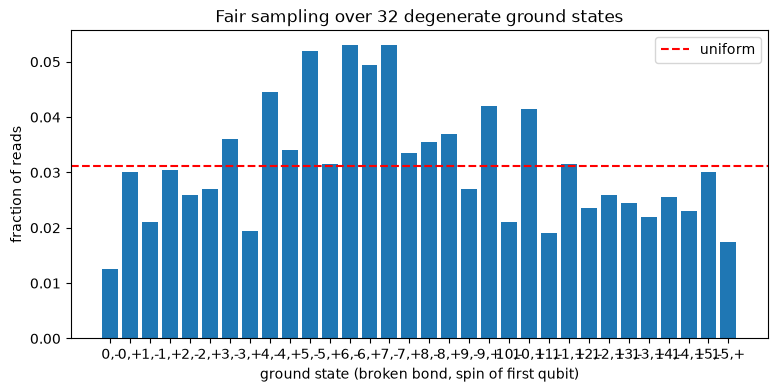

In [13]:
# label each ground state by (which bond is broken, spin of the first qubit), then compare to uniform
from collections import Counter

counts = Counter()
for s, n in zip(ring_samples.samples(), ring_samples.record.num_occurrences):
    broken = [i for i, ((u, v), w) in enumerate(J_ring.items()) if w * s[u] * s[v] > 0]
    if len(broken) == 1:   # exactly one broken bond == ground state
        counts[(broken[0], s[ring[0]])] += n

states = [(i, spin) for i in range(L) for spin in (-1, 1)]
freqs = np.array([counts[state] for state in states]) / NUM_ANNEALS
tvd = 0.5 * np.abs(freqs / freqs.sum() - 1 / len(states)).sum()

print(f"reads in a ground state: {100 * freqs.sum():.1f}%")
print(f"total-variation distance from uniform: {tvd:.3f}")

plt.figure(figsize=(9, 4))
plt.bar(range(len(states)), freqs)
plt.axhline(freqs.sum() / len(states), color='r', ls='--', label='uniform')
plt.xticks(range(len(states)), [f"{i},{'+' if spin > 0 else '-'}" for i, spin in states])
plt.xlabel('ground state (broken bond, spin of first qubit)')
plt.ylabel('fraction of reads')
plt.legend()
plt.title(f"Fair sampling over {2 * L} degenerate ground states")
plt.show()

### Chain Breaking

Any problem too dense for the native graph has to be embedded, which means one logical qubit becomes a
*chain* of physical qubits held together by strong ferromagnetic couplers. The chain is only useful while it
stays aligned: once it breaks, the logical value is ambiguous and has to be guessed by majority vote. So the
question worth asking is how long a chain can get before it stops holding.

We carve disjoint length-$L$ paths straight out of the working graph and run them all in a single job. This is
where the parallelism comes from for free -- hundreds of independent chains fit on the chip at once, so one job
gives `chains` $\times$ `num_reads` chain samples. The carving leaves a one-qubit gap around every chain, so no
coupler exists between two chains and they cannot influence each other.

Each length is run in two conditions:

- **idle**: $h=0$, so a break can only come from thermal noise and control error
- **stressed**: $h=\pm$`STRESS` on the two end qubits, putting the chain in a tug-of-war it has to resolve

`STRESS` must be smaller than $|J_\text{chain}|$. If the two are equal the broken state is exactly degenerate
with the intact one and roughly a third of chains break even at $L=2$ -- that measures degeneracy, not chain
robustness. Kept below it, a domain wall costs energy while the number of places to put one grows with $L$, so
the break rate climbs with length for a real physical reason.

We record two things: how often chains break, and how badly (the fraction of qubits sitting in the minority,
which is what decides whether a majority vote still recovers the right logical value).

In [14]:
# carve disjoint chains, spaced out so they cannot influence each other
def native_chains(G, L, max_chains=200):
    "Carve disjoint length-L paths by random walks, leaving a gap so no two chains are coupled."
    free = set(G.nodes)
    chains = []
    for start in rng.permutation(list(G.nodes)):
        if len(chains) == max_chains:
            break
        if start not in free:
            continue
        chain = [int(start)]
        while len(chain) < L:
            options = [n for n in G[chain[-1]] if n in free and n not in chain]
            if not options:
                break
            chain.append(int(rng.choice(options)))
        if len(chain) == L:
            free -= set(chain) | {n for v in chain for n in G[v]}   # drop the chain and its neighbours
            chains.append(chain)
    return chains

In [15]:
# run: every length, idle and stressed, one job each
NUM_ANNEALS = 1000
LENGTHS = [2, 4, 8, 16, 32, 64]
CHAINS_PER_JOB = 200
J_CHAIN = -1.0
STRESS = 0.5   # must be < abs(J_CHAIN), else breaking is degenerate with staying intact

chain_results = {}   # (L, stressed) -> (chains, sampleset)
with DWaveSampler(solver=SOLVER) as sampler:
    for L in LENGTHS:
        chains = native_chains(G, L, CHAINS_PER_JOB)
        J = {(c[i], c[i + 1]): J_CHAIN for c in chains for i in range(L - 1)}
        for stressed in (False, True):
            # tug-of-war: opposite biases on the two ends of every chain
            h = {q: bias for c in chains for q, bias in ((c[0], +STRESS), (c[-1], -STRESS))} if stressed else {}
            res = sampler.sample_ising(h, J, num_reads=NUM_ANNEALS, auto_scale=False,
                                       label=f"chains L={L} stressed={stressed}")
            chain_results[(L, stressed)] = (chains, res)
        print(f"L = {L}: {len(chains)} chains per job")

L = 2: 200 chains per job
L = 4: 150 chains per job
L = 8: 87 chains per job
L = 16: 48 chains per job
L = 32: 29 chains per job
L = 64: 18 chains per job


stressed chains start breaking (>1%) at L = 16


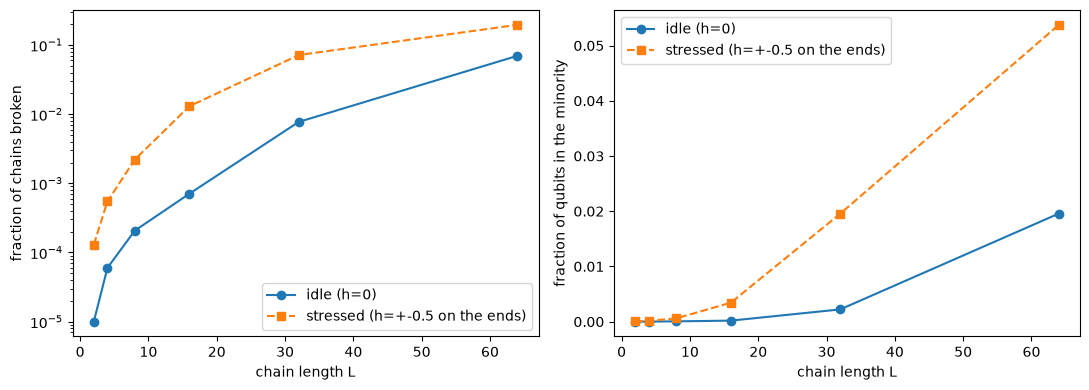

In [16]:
# analyse: how often chains break, and how badly
break_rate, severity = {}, {}
for (L, stressed), (chains, res) in chain_results.items():
    idx = {v: i for i, v in enumerate(res.variables)}
    spins = np.stack([res.record.sample[:, [idx[q] for q in c]] for c in chains])   # (chains, reads, L)
    broken = (spins != spins[..., :1]).any(axis=2)                                  # any qubit out of line
    minority = np.minimum((spins == 1).sum(axis=2), (spins == -1).sum(axis=2)) / L  # how badly
    weights = np.broadcast_to(res.record.num_occurrences, broken.shape)
    break_rate[(L, stressed)] = np.average(broken, weights=weights)
    severity[(L, stressed)] = np.average(minority, weights=weights)

onset = [L for L in LENGTHS if break_rate[(L, True)] > 0.01]
print(f"stressed chains start breaking (>1%) at L = {onset[0] if onset else 'never in this range'}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for stressed, style in ((False, 'o-'), (True, 's--')):
    label = f'stressed (h=+-{STRESS} on the ends)' if stressed else 'idle (h=0)'
    ax1.semilogy(LENGTHS, [max(break_rate[(L, stressed)], 1e-5) for L in LENGTHS], style, label=label)
    ax2.plot(LENGTHS, [severity[(L, stressed)] for L in LENGTHS], style, label=label)
ax1.set(xlabel='chain length L', ylabel='fraction of chains broken')
ax2.set(xlabel='chain length L', ylabel='fraction of qubits in the minority')
ax1.legend()
ax2.legend()
fig.tight_layout()
plt.show()